In [1]:
import sys
sys.path.append("/Users/27171653/Desktop/PhD/Specular-Highlights/sh_models")


In [2]:
from pathlib import Path
import importlib
from torch.utils.data import DataLoader, Subset

from pipeline import ResidualLoader as residual_loader

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from IPython.display import clear_output

three_channel_unet = importlib.import_module("3chanelunet")


## Residual U-Net Training

This notebook follows the same step-by-step style as `trainmodel.ipynb`, but trains the U-Net to predict a residual.

- `input` is the glossy image.
- `target` is the residual.
- `diffuse` is the ground-truth reconstructed output.
- The final prediction is reconstructed from the glossy input and the predicted residual.


In [3]:
residual_mode = "subtractive"  # change to "subtractive" for diffuse = glossy - residual
MASK_SOFT_FOCUS_GAMMA = 2.0
RESIDUAL_OUTPUT_SCALE = 0.5

TRAIN_VARIANTS = {
    "focused_object_mask": {
        "prediction_mode": "masked_only",
        "optimize_source": "mask_soft",
        "object_loss_weight": 1.0,
        "background_loss_weight": 0.0,
        "residual_weight": 3.0,
    },
    "object_mask_only": {
        "prediction_mode": "masked_only",
        "optimize_source": "mask",
        "object_loss_weight": 1.0,
        "background_loss_weight": 0.0,
        "residual_weight": 1.0,
    },
    "full_residual": {
        "prediction_mode": "full",
        "optimize_source": "mask_soft",
        "object_loss_weight": 1.0,
        "background_loss_weight": 0.25,
        "residual_weight": 2.0,
    }
}

focused_object_variant = TRAIN_VARIANTS["focused_object_mask"]
object_mask_only_variant = TRAIN_VARIANTS["object_mask_only"]
full_residual_variant = TRAIN_VARIANTS["full_residual"]
diffuse_images = "/Users/27171653/Desktop/PhD/Specular-Highlights/data/train/can/diffuse"
glossy_images = "/Users/27171653/Desktop/PhD/Specular-Highlights/data/train/can/glossy"

dataset, loader = residual_loader.make_residual_dataloader(
    diffuse_dir=diffuse_images,
    glossy_dir=glossy_images,
    batch_size=4,
    soft_gamma=1.0,
    threshold_method="otsu",
    threshold=0.7,
    residual_mode=residual_mode,
)

small_dataset = Subset(dataset, [6])  # position_06.png for quick testing

small_loader = DataLoader(
    small_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
weights_dir = Path("weights")
weights_dir.mkdir(parents=True, exist_ok=True)

TEST_EPOCHS = 100

print(f"residual_mode: {residual_mode}")
print(f"formula: diffuse = glossy {'+' if residual_mode == 'additive' else '-'} residual")
print(f"MASK_SOFT_FOCUS_GAMMA: {MASK_SOFT_FOCUS_GAMMA}")
print(f"RESIDUAL_OUTPUT_SCALE: {RESIDUAL_OUTPUT_SCALE}")
print(f"focused_object_variant: {focused_object_variant}")
print(f"object_mask_only_variant: {object_mask_only_variant}")
print(f"dataset size: {len(dataset)}")


residual_mode: subtractive
formula: diffuse = glossy - residual
MASK_SOFT_FOCUS_GAMMA: 2.0
RESIDUAL_OUTPUT_SCALE: 0.5
focused_object_variant: {'prediction_mode': 'masked_only', 'optimize_source': 'mask_soft', 'object_loss_weight': 1.0, 'background_loss_weight': 0.0, 'residual_weight': 3.0}
object_mask_only_variant: {'prediction_mode': 'masked_only', 'optimize_source': 'mask', 'object_loss_weight': 1.0, 'background_loss_weight': 0.0, 'residual_weight': 1.0}
dataset size: 10


In [4]:
import time
import random
from collections import defaultdict

import torch
import torch.nn as nn
import matplotlib.pyplot as plt


def _move_batch_to_device(batch, device):
    out = {}
    for k, v in batch.items():
        out[k] = v.to(device, non_blocking=True) if torch.is_tensor(v) else v
    return out


def _get_loss_fn(loss_name="l1", reduction="mean"):
    loss_name = loss_name.lower()
    if loss_name == "l1":
        return nn.L1Loss(reduction=reduction)
    if loss_name == "mse":
        return nn.MSELoss(reduction=reduction)
    if loss_name == "smoothl1":
        return nn.SmoothL1Loss(reduction=reduction)
    raise ValueError("loss_name must be 'l1', 'mse', or 'smoothl1'")


def _weighted_mean(pixel_values, weight_map, eps=1e-8):
    if pixel_values.ndim != 4:
        raise ValueError(f"Expected pixel_values [B,C,H,W], got {tuple(pixel_values.shape)}")
    if weight_map.ndim != 4:
        raise ValueError(f"Expected weight_map [B,1,H,W], got {tuple(weight_map.shape)}")

    if weight_map.shape[1] != 1:
        weight_map = weight_map.mean(dim=1, keepdim=True)

    denom = weight_map.sum() * pixel_values.shape[1]
    return (pixel_values * weight_map).sum() / (denom + eps)


def _build_loss_weight(
    batch,
    optimize_source="mask",
    object_loss_weight=4.0,
    background_loss_weight=1.0,
):
    if optimize_source == "full":
        focus_map = torch.zeros_like(batch["soft_mask"]).float()
    elif optimize_source == "soft_mask":
        focus_map = batch["soft_mask"].float().clamp(0.0, 1.0).pow(MASK_SOFT_FOCUS_GAMMA)
    elif optimize_source == "mask":
        focus_map = batch["mask"].float().clamp(0.0, 1.0)
    elif optimize_source == "mask_soft":
        focus_map = (
            batch["mask"].float().clamp(0.0, 1.0)
            * batch["soft_mask"].float().clamp(0.0, 1.0)
        ).pow(MASK_SOFT_FOCUS_GAMMA)
    else:
        raise ValueError("optimize_source must be 'full', 'soft_mask', 'mask', or 'mask_soft'")

    return background_loss_weight + (object_loss_weight - background_loss_weight) * focus_map


def _forward_residual_model(model, x, soft_mask=None):
    try:
        residual = model(x, soft_mask=soft_mask)
    except TypeError:
        residual = model(x)

    if residual.shape != x.shape:
        raise ValueError(
            f"Residual and input shapes must match, got {tuple(residual.shape)} and {tuple(x.shape)}"
        )

    return residual


def _apply_prediction_mode(batch, residual_pred, prediction_mode="full"):
    object_mask = batch["mask"].float().clamp(0.0, 1.0)

    if prediction_mode == "full":
        residual_true = batch["unmasked_target"].float()
        prediction_mask = torch.ones_like(object_mask)
        residual_pred_used = residual_pred
    elif prediction_mode == "masked_only":
        residual_true = batch["target"].float()
        prediction_mask = object_mask
        residual_pred_used = residual_pred * prediction_mask.expand_as(residual_pred)
    else:
        raise ValueError("prediction_mode must be 'full' or 'masked_only'")

    return residual_pred_used, residual_true, object_mask, prediction_mask


def _residual_to_vis(residual_tensor):
    residual_img = residual_tensor.detach().cpu().permute(1, 2, 0)
    residual_img = residual_img - residual_img.min()
    residual_img = residual_img / (residual_img.max() + 1e-8)
    return residual_img.clamp(0.0, 1.0)


def _run_residual_batch(
    model,
    batch,
    pixel_loss_fn,
    *,
    residual_mode="additive",
    prediction_mode="full",
    optimize_source="mask",
    object_loss_weight=4.0,
    background_loss_weight=1.0,
    residual_weight=0.25,
):
    x = batch["input"].float()
    y_true = batch["diffuse"].float()
    soft_mask = batch["soft_mask"].float().clamp(0.0, 1.0)
    loss_weight = _build_loss_weight(
        batch,
        optimize_source=optimize_source,
        object_loss_weight=object_loss_weight,
        background_loss_weight=background_loss_weight,
    )

    residual_pred_raw = _forward_residual_model(model, x, soft_mask=soft_mask)
    residual_pred, residual_true, object_mask, prediction_mask = _apply_prediction_mode(
        batch,
        residual_pred_raw,
        prediction_mode=prediction_mode,
    )
    y_pred = residual_loader.reconstruct_diffuse(
        x,
        residual_pred,
        residual_mode=residual_mode,
    )

    output_loss_map = pixel_loss_fn(y_pred, y_true)
    residual_loss_map = pixel_loss_fn(residual_pred, residual_true)

    output_loss = _weighted_mean(output_loss_map, loss_weight)
    residual_loss = _weighted_mean(residual_loss_map, loss_weight)
    loss = output_loss + residual_weight * residual_loss

    abs_err = (y_pred - y_true).abs()
    object_weight = batch["mask"].float().clamp(0.0, 1.0)
    focus_weight = (object_weight * soft_mask).pow(MASK_SOFT_FOCUS_GAMMA)
    identity_abs_err = (x - y_true).abs()

    return {
        "loss": loss,
        "x": x,
        "y_true": y_true,
        "y_pred": y_pred,
        "residual_true": residual_true,
        "residual_pred": residual_pred,
        "raw_residual_pred": residual_pred_raw,
        "object_mask": object_mask,
        "prediction_mask": prediction_mask,
        "soft_mask": soft_mask,
        "loss_weight": loss_weight,
        "output_loss": output_loss,
        "residual_loss": residual_loss,
        "opt_l1": _weighted_mean(abs_err, loss_weight),
        "full_l1": abs_err.mean(),
        "object_l1": _weighted_mean(abs_err, object_weight),
        "focus_l1": _weighted_mean(abs_err, focus_weight),
        "identity_l1": _weighted_mean(identity_abs_err, loss_weight),
        "identity_focus_l1": _weighted_mean(identity_abs_err, focus_weight),
    }


@torch.no_grad()
def evaluate_residual_unet(
    model,
    loader,
    *,
    loss_name="l1",
    device=None,
    residual_mode="additive",
    prediction_mode="full",
    optimize_source="mask",
    object_loss_weight=4.0,
    background_loss_weight=1.0,
    residual_weight=0.25,
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    pixel_loss_fn = _get_loss_fn(loss_name, reduction="none")
    running = defaultdict(float)
    n_samples = 0

    for batch in loader:
        batch = _move_batch_to_device(batch, device)
        outputs = _run_residual_batch(
            model,
            batch,
            pixel_loss_fn,
            residual_mode=residual_mode,
            prediction_mode=prediction_mode,
            optimize_source=optimize_source,
            object_loss_weight=object_loss_weight,
            background_loss_weight=background_loss_weight,
            residual_weight=residual_weight,
        )

        bs = outputs["x"].shape[0]
        n_samples += bs
        for key in ("loss", "output_loss", "residual_loss", "opt_l1", "full_l1", "object_l1", "focus_l1", "identity_l1", "identity_focus_l1"):
            running[key] += outputs[key].item() * bs

    return {key: value / max(n_samples, 1) for key, value in running.items()}


@torch.no_grad()
def show_residual_predictions(
    model,
    dataset,
    device,
    *,
    residual_mode="additive",
    prediction_mode="full",
    optimize_source="mask",
    object_loss_weight=4.0,
    background_loss_weight=1.0,
    n_show=3,
    seed=None,
):
    if seed is not None:
        random.seed(seed)

    model.eval()
    n_show = min(n_show, len(dataset))
    indices = random.sample(range(len(dataset)), n_show)

    fig, axes = plt.subplots(n_show, 8, figsize=(28, 4 * n_show))
    if n_show == 1:
        axes = axes[None, :]

    for row, idx in enumerate(indices):
        sample = dataset[idx]
        preview_batch = {
            "input": sample["input"].unsqueeze(0).to(device).float(),
            "diffuse": sample["diffuse"].unsqueeze(0).to(device).float(),
            "target": sample["target"].unsqueeze(0).to(device).float(),
            "unmasked_target": sample["unmasked_target"].unsqueeze(0).to(device).float(),
            "mask": sample["mask"].unsqueeze(0).to(device).float(),
            "soft_mask": sample["soft_mask"].unsqueeze(0).to(device).float(),
        }

        x = preview_batch["input"]
        soft_mask = preview_batch["soft_mask"]
        loss_weight = _build_loss_weight(
            preview_batch,
            optimize_source=optimize_source,
            object_loss_weight=object_loss_weight,
            background_loss_weight=background_loss_weight,
        )
        residual_pred_raw = _forward_residual_model(model, x, soft_mask=soft_mask)
        residual_pred, residual_true, object_mask, prediction_mask = _apply_prediction_mode(
            preview_batch,
            residual_pred_raw,
            prediction_mode=prediction_mode,
        )
        y_pred = residual_loader.reconstruct_diffuse(
            x,
            residual_pred,
            residual_mode=residual_mode,
        )

        x_img = x[0].detach().cpu().permute(1, 2, 0)
        diffuse_true = sample["diffuse"].detach().cpu().permute(1, 2, 0)
        residual_true_img = residual_true[0].detach().cpu()
        residual_pred_img = residual_pred[0].detach().cpu()
        y_pred_img = y_pred[0].detach().cpu().permute(1, 2, 0).clamp(0.0, 1.0)
        object_mask_img = object_mask[0, 0].detach().cpu()
        loss_weight_img = loss_weight[0, 0].detach().cpu()
        err_map = (y_pred[0].detach().cpu() - sample["diffuse"].cpu()).abs().mean(dim=0)
        object_l1 = _weighted_mean((y_pred - preview_batch["diffuse"]).abs(), object_mask).item()
        focus_weight = (object_mask * soft_mask).pow(MASK_SOFT_FOCUS_GAMMA)
        focus_l1 = _weighted_mean((y_pred - preview_batch["diffuse"]).abs(), focus_weight).item()

        axes[row, 0].imshow(x_img)
        axes[row, 0].set_title(f"Glossy\n{sample['name']}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(diffuse_true)
        axes[row, 1].set_title("Target diffuse")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(_residual_to_vis(residual_true_img))
        axes[row, 2].set_title("Target residual")
        axes[row, 2].axis("off")

        axes[row, 3].imshow(_residual_to_vis(residual_pred_img))
        axes[row, 3].set_title(f"Predicted residual\n({prediction_mode})")
        axes[row, 3].axis("off")

        axes[row, 4].imshow(y_pred_img)
        axes[row, 4].set_title("Reconstructed output")
        axes[row, 4].axis("off")

        axes[row, 5].imshow(object_mask_img, cmap="gray", vmin=0, vmax=1)
        axes[row, 5].set_title("Object mask")
        axes[row, 5].axis("off")

        axes[row, 6].imshow(loss_weight_img, cmap="magma")
        axes[row, 6].set_title("Loss weight map")
        axes[row, 6].axis("off")

        axes[row, 7].imshow(err_map, cmap="magma")
        axes[row, 7].set_title(f"Abs error\nfull={err_map.mean():.4f} object={object_l1:.4f} focus={focus_l1:.4f}")
        axes[row, 7].axis("off")

    plt.tight_layout()
    plt.show()


def plot_residual_training_history(history, model_label="Residual U-Net"):
    plt.figure(figsize=(10, 4))
    plt.plot(history["train_loss"], label="train_loss")
    if "val_loss" in history and len(history["val_loss"]) > 0:
        plt.plot(history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_label} training history")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [5]:
def train_residual_unet(
    model,
    train_loader,
    val_loader=None,
    *,
    lr=1e-3,
    weight_decay=0.0,
    epochs=TEST_EPOCHS,
    device=None,
    loss_name="l1",
    grad_clip=None,
    log_every=10,
    plot_every=None,
    preview_dataset=None,
    save_best_path=None,
    model_label="Residual U-Net",
    residual_mode="additive",
    prediction_mode="full",
    optimize_source="mask",
    object_loss_weight=4.0,
    background_loss_weight=1.0,
    residual_weight=0.25,
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    plot_every = epochs if plot_every is None else plot_every
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    pixel_loss_fn = _get_loss_fn(loss_name, reduction="none")

    history = defaultdict(list)
    best_loss = float("inf")
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        running = defaultdict(float)
        n_samples = 0

        for batch in train_loader:
            batch = _move_batch_to_device(batch, device)
            optimizer.zero_grad(set_to_none=True)

            outputs = _run_residual_batch(
                model,
                batch,
                pixel_loss_fn,
                residual_mode=residual_mode,
                prediction_mode=prediction_mode,
                optimize_source=optimize_source,
                object_loss_weight=object_loss_weight,
                background_loss_weight=background_loss_weight,
                residual_weight=residual_weight,
            )
            loss = outputs["loss"]
            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

            bs = outputs["x"].shape[0]
            n_samples += bs
            for key in ("loss", "output_loss", "residual_loss", "opt_l1", "full_l1", "object_l1", "focus_l1", "identity_l1", "identity_focus_l1"):
                running[key] += outputs[key].item() * bs

        train_metrics = {key: value / max(n_samples, 1) for key, value in running.items()}
        history["train_loss"].append(train_metrics["loss"])
        history["train_output_loss"].append(train_metrics["output_loss"])
        history["train_residual_loss"].append(train_metrics["residual_loss"])
        history["train_opt_l1"].append(train_metrics["opt_l1"])
        history["train_full_l1"].append(train_metrics["full_l1"])
        history["train_object_l1"].append(train_metrics["object_l1"])
        history["train_focus_l1"].append(train_metrics["focus_l1"])
        history["train_identity_l1"].append(train_metrics["identity_l1"])
        history["train_identity_focus_l1"].append(train_metrics["identity_focus_l1"])
        history["lr"].append(optimizer.param_groups[0]["lr"])

        val_metrics = None
        monitor_loss = train_metrics["loss"]
        if val_loader is not None:
            val_metrics = evaluate_residual_unet(
                model=model,
                loader=val_loader,
                loss_name=loss_name,
                device=device,
                residual_mode=residual_mode,
                prediction_mode=prediction_mode,
                optimize_source=optimize_source,
                object_loss_weight=object_loss_weight,
                background_loss_weight=background_loss_weight,
                residual_weight=residual_weight,
            )
            history["val_loss"].append(val_metrics["loss"])
            history["val_output_loss"].append(val_metrics["output_loss"])
            history["val_residual_loss"].append(val_metrics["residual_loss"])
            history["val_opt_l1"].append(val_metrics["opt_l1"])
            history["val_full_l1"].append(val_metrics["full_l1"])
            history["val_object_l1"].append(val_metrics["object_l1"])
            history["val_focus_l1"].append(val_metrics["focus_l1"])
            history["val_identity_l1"].append(val_metrics["identity_l1"])
            history["val_identity_focus_l1"].append(val_metrics["identity_focus_l1"])
            monitor_loss = val_metrics["loss"]

        if monitor_loss < best_loss:
            best_loss = monitor_loss
            if save_best_path is not None:
                torch.save(
                    {
                        "epoch": epoch,
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "train_metrics": train_metrics,
                        "val_metrics": val_metrics,
                        "config": {
                            "loss_name": loss_name,
                            "residual_mode": residual_mode,
                            "prediction_mode": prediction_mode,
                            "optimize_source": optimize_source,
                            "object_loss_weight": object_loss_weight,
                            "background_loss_weight": background_loss_weight,
                            "residual_weight": residual_weight,
                        },
                    },
                    save_best_path,
                )

        if log_every and ((epoch % log_every == 0) or (epoch == 1) or (epoch == epochs)):
            message = (
                f"[{model_label}] epoch {epoch:03d}/{epochs} | "
                f"train loss {train_metrics['loss']:.6f} | "
                f"train focus_l1 {train_metrics['focus_l1']:.6f} | "
                f"identity_focus {train_metrics['identity_focus_l1']:.6f}"
            )
            if val_metrics is not None:
                message += (
                    f" | val loss {val_metrics['loss']:.6f}"
                    f" | val focus_l1 {val_metrics['focus_l1']:.6f}"
                )
            print(message)

        if plot_every and ((epoch % plot_every == 0) or (epoch == epochs)):
            clear_output(wait=True)
            print(f"{model_label} | epoch {epoch}/{epochs}")
            plot_residual_training_history(history, model_label=model_label)
            if preview_dataset is not None:
                show_residual_predictions(
                    model,
                    preview_dataset,
                    device=device,
                    residual_mode=residual_mode,
                    prediction_mode=prediction_mode,
                    optimize_source=optimize_source,
                    object_loss_weight=object_loss_weight,
                    background_loss_weight=background_loss_weight,
                    n_show=min(3, len(preview_dataset)),
                    seed=0,
                )

    elapsed = time.time() - start_time
    print(f"Training completed in {elapsed / 60.0:.2f} minutes")
    return model, history


In [6]:
class ThreeChannelUNetResidualAdapter(nn.Module):
    def __init__(
        self,
        *,
        in_channels=3,
        base_channels=16,
        depth=3,
        out_channels=3,
        bottleneck_length=1,
        num_heads=4,
        use_bottleneck_self_attention=True,
        use_soft_mask_input=False,
    ):
        super().__init__()
        self.use_soft_mask_input = use_soft_mask_input
        self.residual_output_scale = RESIDUAL_OUTPUT_SCALE
        self.model = three_channel_unet.UNet(
            in_channels=in_channels + (1 if use_soft_mask_input else 0),
            base_channels=base_channels,
            depth=depth,
            out_channels=out_channels,
            Attention=(three_channel_unet.TransformerEncoderSA if use_bottleneck_self_attention else None),
            OnlyonBottleneck=use_bottleneck_self_attention,
            num_heads=num_heads,
            bottleneck_length=bottleneck_length,
        )

    def forward(self, x, soft_mask=None):
        if self.use_soft_mask_input:
            if soft_mask is None:
                raise ValueError("ThreeChannelUNetResidualAdapter with use_soft_mask_input=True requires soft_mask.")
            residual_strength = soft_mask
            x = torch.cat([x, residual_strength], dim=1)
        raw_residual = self.model(x)
        return self.residual_output_scale * torch.tanh(raw_residual)


4channel residual UNet focused-object (subtractive) | epoch 100/100


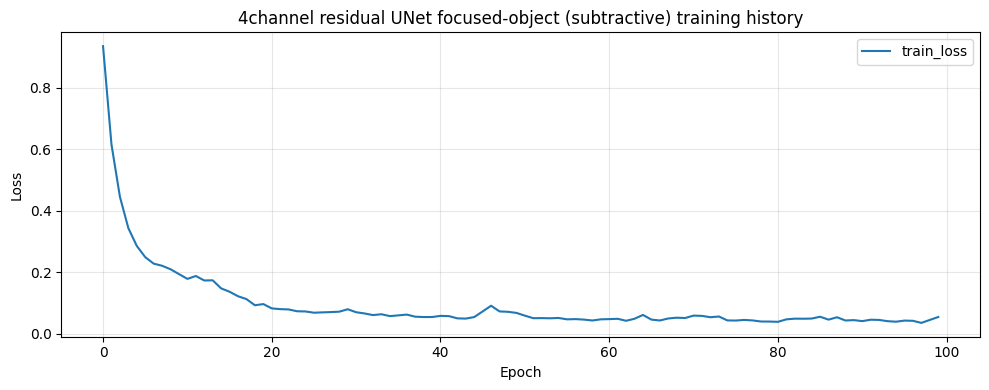

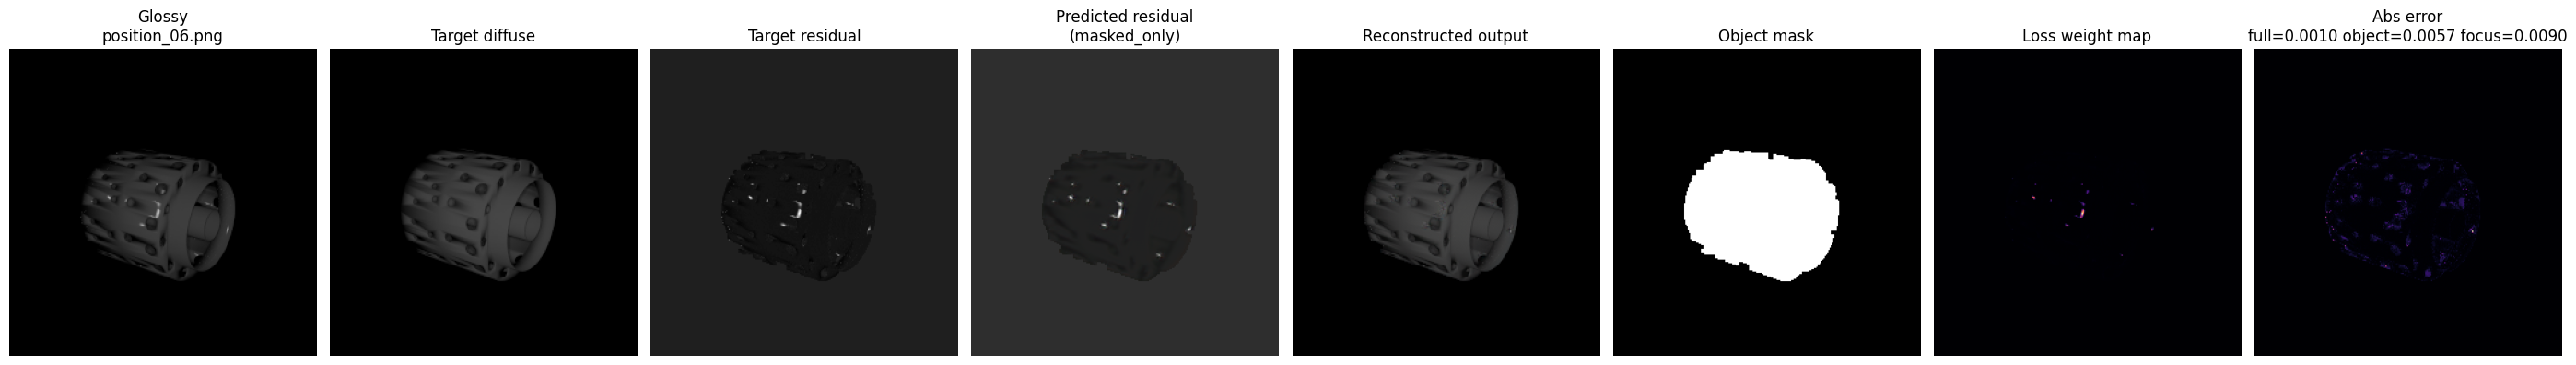

Training completed in 47.20 minutes
Final 4channel focused-object train loss: 0.054246
Final 4channel focused-object train focus_l1: 0.013562
Final 4channel focused-object identity_focus_l1: 0.116934


In [7]:
# Train and preview the 4-channel U-Net with focused-object residual loss.
# This version predicts only inside the object mask and concentrates the loss on highlight-heavy pixels.

weighted_unet4_model, weighted_unet4_history = train_residual_unet(
    model=ThreeChannelUNetResidualAdapter(
        in_channels=3,
        base_channels=16,
        depth=3,
        out_channels=3,
        bottleneck_length=1,
        use_soft_mask_input=True,
    ),
    train_loader=loader,
    lr=1e-3,
    epochs=TEST_EPOCHS,
    device=device,
    loss_name="l1",
    log_every=10,
    plot_every=TEST_EPOCHS,
    preview_dataset=small_dataset,
    save_best_path=str(weights_dir / f"4channel_unet_residual_{residual_mode}_focused_object_mask.pth"),
    model_label=f"4channel residual UNet focused-object ({residual_mode})",
    residual_mode=residual_mode,
    prediction_mode=focused_object_variant["prediction_mode"],
    optimize_source=focused_object_variant["optimize_source"],
    object_loss_weight=focused_object_variant["object_loss_weight"],
    background_loss_weight=focused_object_variant["background_loss_weight"],
    residual_weight=focused_object_variant["residual_weight"],
)

print(f"Final 4channel focused-object train loss: {weighted_unet4_history['train_loss'][-1]:.6f}")
print(f"Final 4channel focused-object train focus_l1: {weighted_unet4_history['train_focus_l1'][-1]:.6f}")
print(f"Final 4channel focused-object identity_focus_l1: {weighted_unet4_history['train_identity_focus_l1'][-1]:.6f}")


4channel residual UNet object-mask-only (subtractive) | epoch 100/100


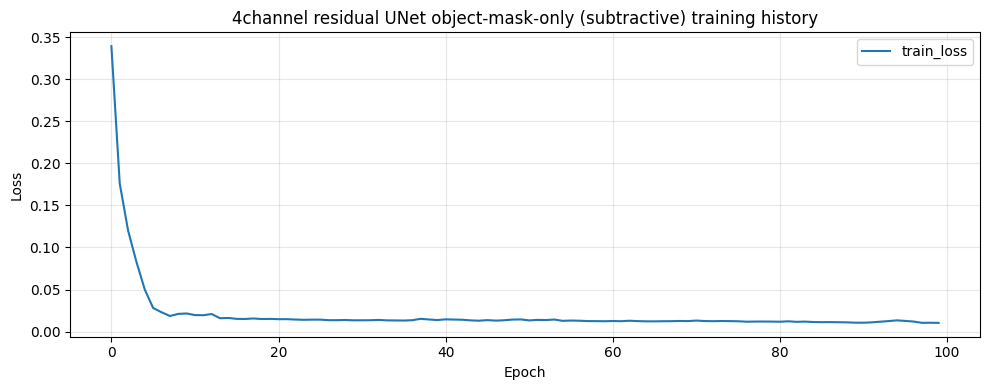

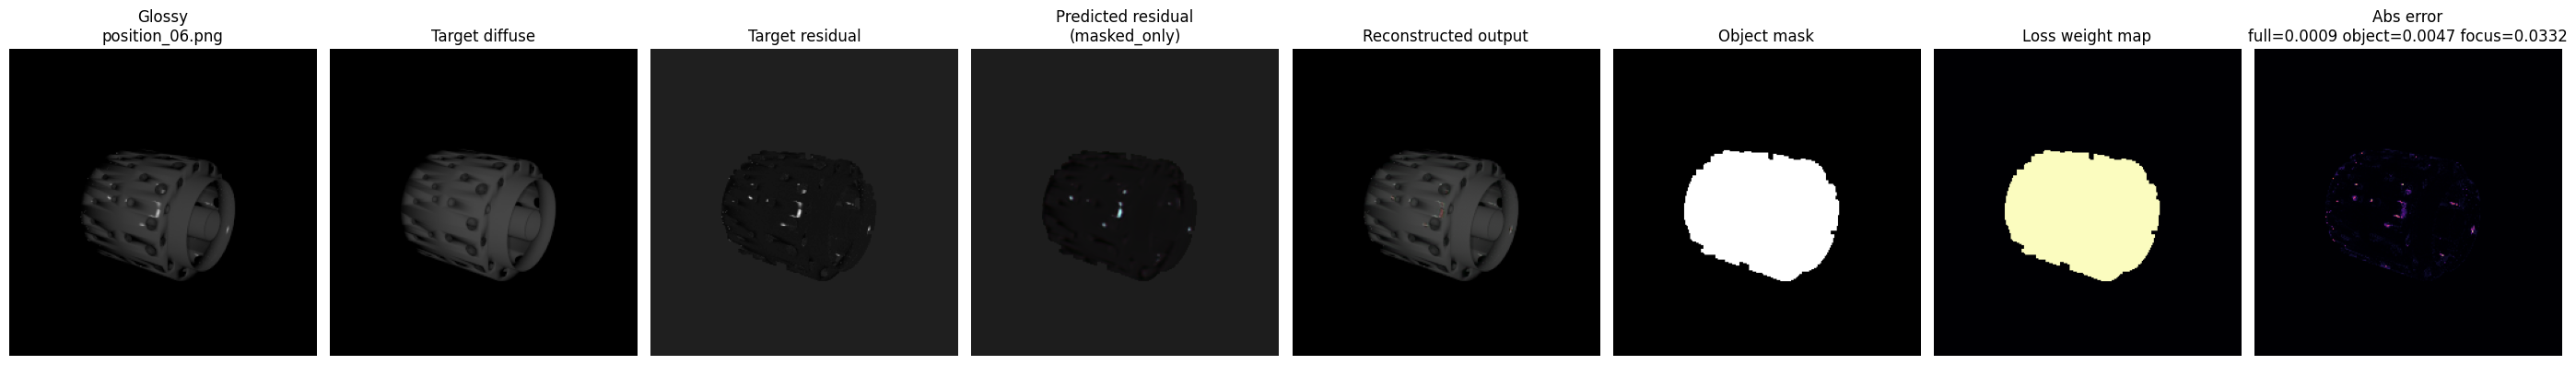

Training completed in 64.08 minutes
Final 4channel object-mask-only train loss: 0.010393
Final 4channel object-mask-only train opt_l1: 0.005196
Final 4channel object-mask-only identity_l1: 0.031383


In [8]:
# Train and preview the 4-channel U-Net with object-mask-only prediction.
# This version applies the object mask to the predicted residual and optimizes only that region.

masked_unet4_model, masked_unet4_history = train_residual_unet(
    model=ThreeChannelUNetResidualAdapter(
        in_channels=3,
        base_channels=16,
        depth=3,
        out_channels=3,
        bottleneck_length=1,
        use_soft_mask_input=True,
    ),
    train_loader=loader,
    lr=1e-3,
    epochs=TEST_EPOCHS,
    device=device,
    loss_name="l1",
    log_every=10,
    plot_every=TEST_EPOCHS,
    preview_dataset=small_dataset,
    save_best_path=str(weights_dir / f"4channel_unet_residual_{residual_mode}_object_mask_only.pth"),
    model_label=f"4channel residual UNet object-mask-only ({residual_mode})",
    residual_mode=residual_mode,
    prediction_mode=object_mask_only_variant["prediction_mode"],
    optimize_source=object_mask_only_variant["optimize_source"],
    object_loss_weight=object_mask_only_variant["object_loss_weight"],
    background_loss_weight=object_mask_only_variant["background_loss_weight"],
    residual_weight=object_mask_only_variant["residual_weight"],
)

print(f"Final 4channel object-mask-only train loss: {masked_unet4_history['train_loss'][-1]:.6f}")
print(f"Final 4channel object-mask-only train opt_l1: {masked_unet4_history['train_opt_l1'][-1]:.6f}")
print(f"Final 4channel object-mask-only identity_l1: {masked_unet4_history['train_identity_l1'][-1]:.6f}")


3channel residual UNet focused-object (subtractive) | epoch 100/100


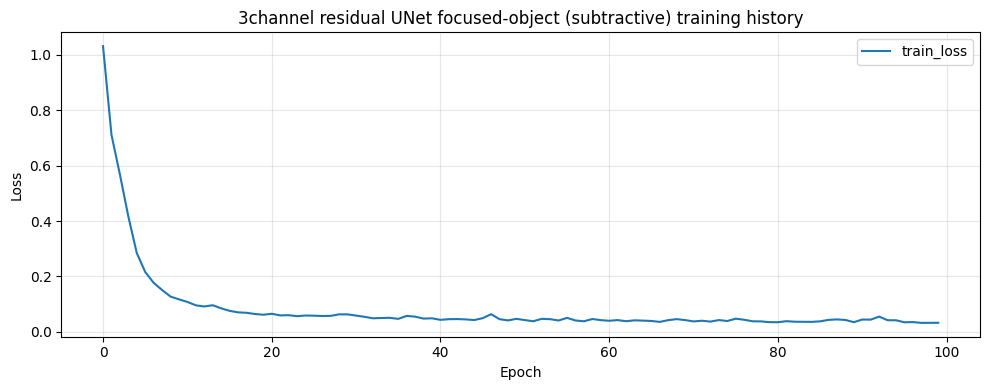

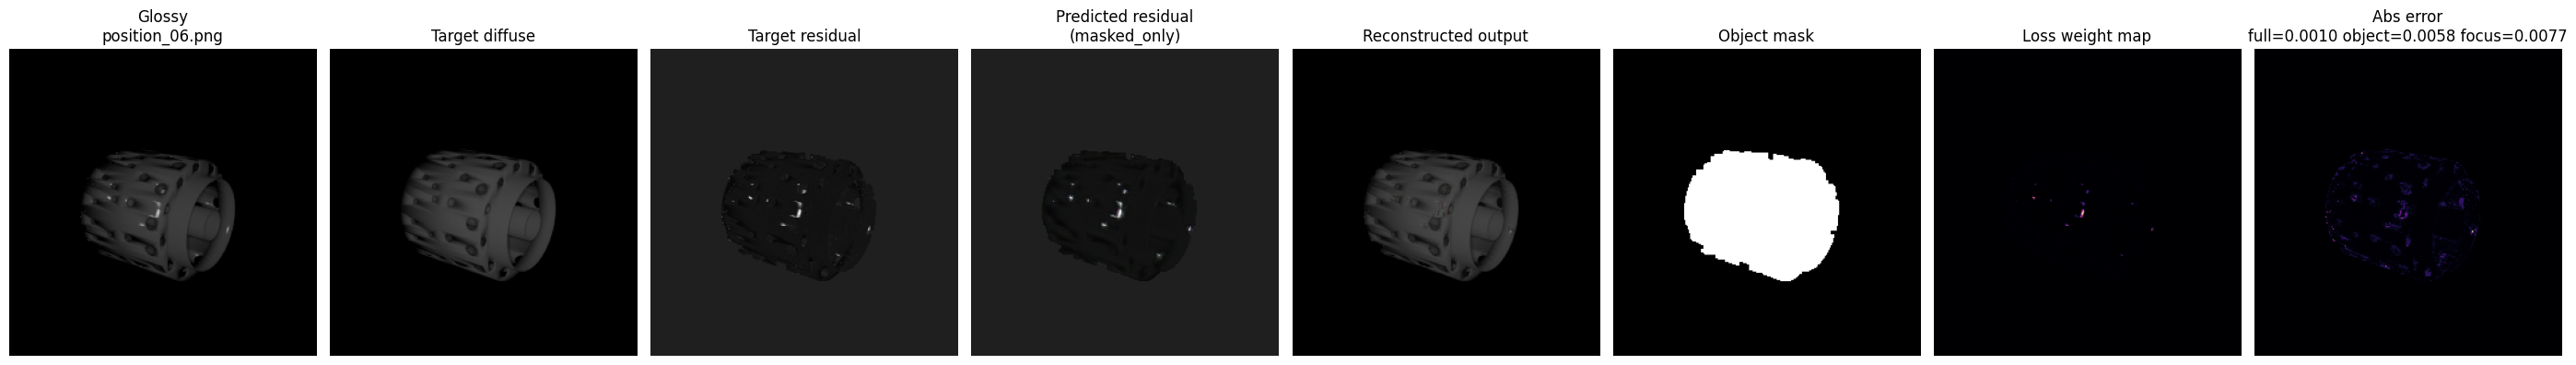

Training completed in 52.98 minutes
Final 3channel focused-object train loss: 0.032720
Final 3channel focused-object train focus_l1: 0.008180
Final 3channel focused-object identity_focus_l1: 0.118606


In [9]:
# Train and preview the 3-channel U-Net with focused-object residual loss.
# This version predicts only inside the object mask and concentrates the loss on highlight-heavy pixels.

weighted_unet3_model, weighted_unet3_history = train_residual_unet(
    model=ThreeChannelUNetResidualAdapter(
        in_channels=3,
        base_channels=16,
        depth=3,
        out_channels=3,
        bottleneck_length=1,
        use_soft_mask_input=False,
    ),
    train_loader=loader,
    lr=1e-3,
    epochs=TEST_EPOCHS,
    device=device,
    loss_name="l1",
    log_every=10,
    plot_every=TEST_EPOCHS,
    preview_dataset=small_dataset,
    save_best_path=str(weights_dir / f"3channel_unet_residual_{residual_mode}_focused_object_mask.pth"),
    model_label=f"3channel residual UNet focused-object ({residual_mode})",
    residual_mode=residual_mode,
    prediction_mode=focused_object_variant["prediction_mode"],
    optimize_source=focused_object_variant["optimize_source"],
    object_loss_weight=focused_object_variant["object_loss_weight"],
    background_loss_weight=focused_object_variant["background_loss_weight"],
    residual_weight=focused_object_variant["residual_weight"],
)

print(f"Final 3channel focused-object train loss: {weighted_unet3_history['train_loss'][-1]:.6f}")
print(f"Final 3channel focused-object train focus_l1: {weighted_unet3_history['train_focus_l1'][-1]:.6f}")
print(f"Final 3channel focused-object identity_focus_l1: {weighted_unet3_history['train_identity_focus_l1'][-1]:.6f}")
